# Условие

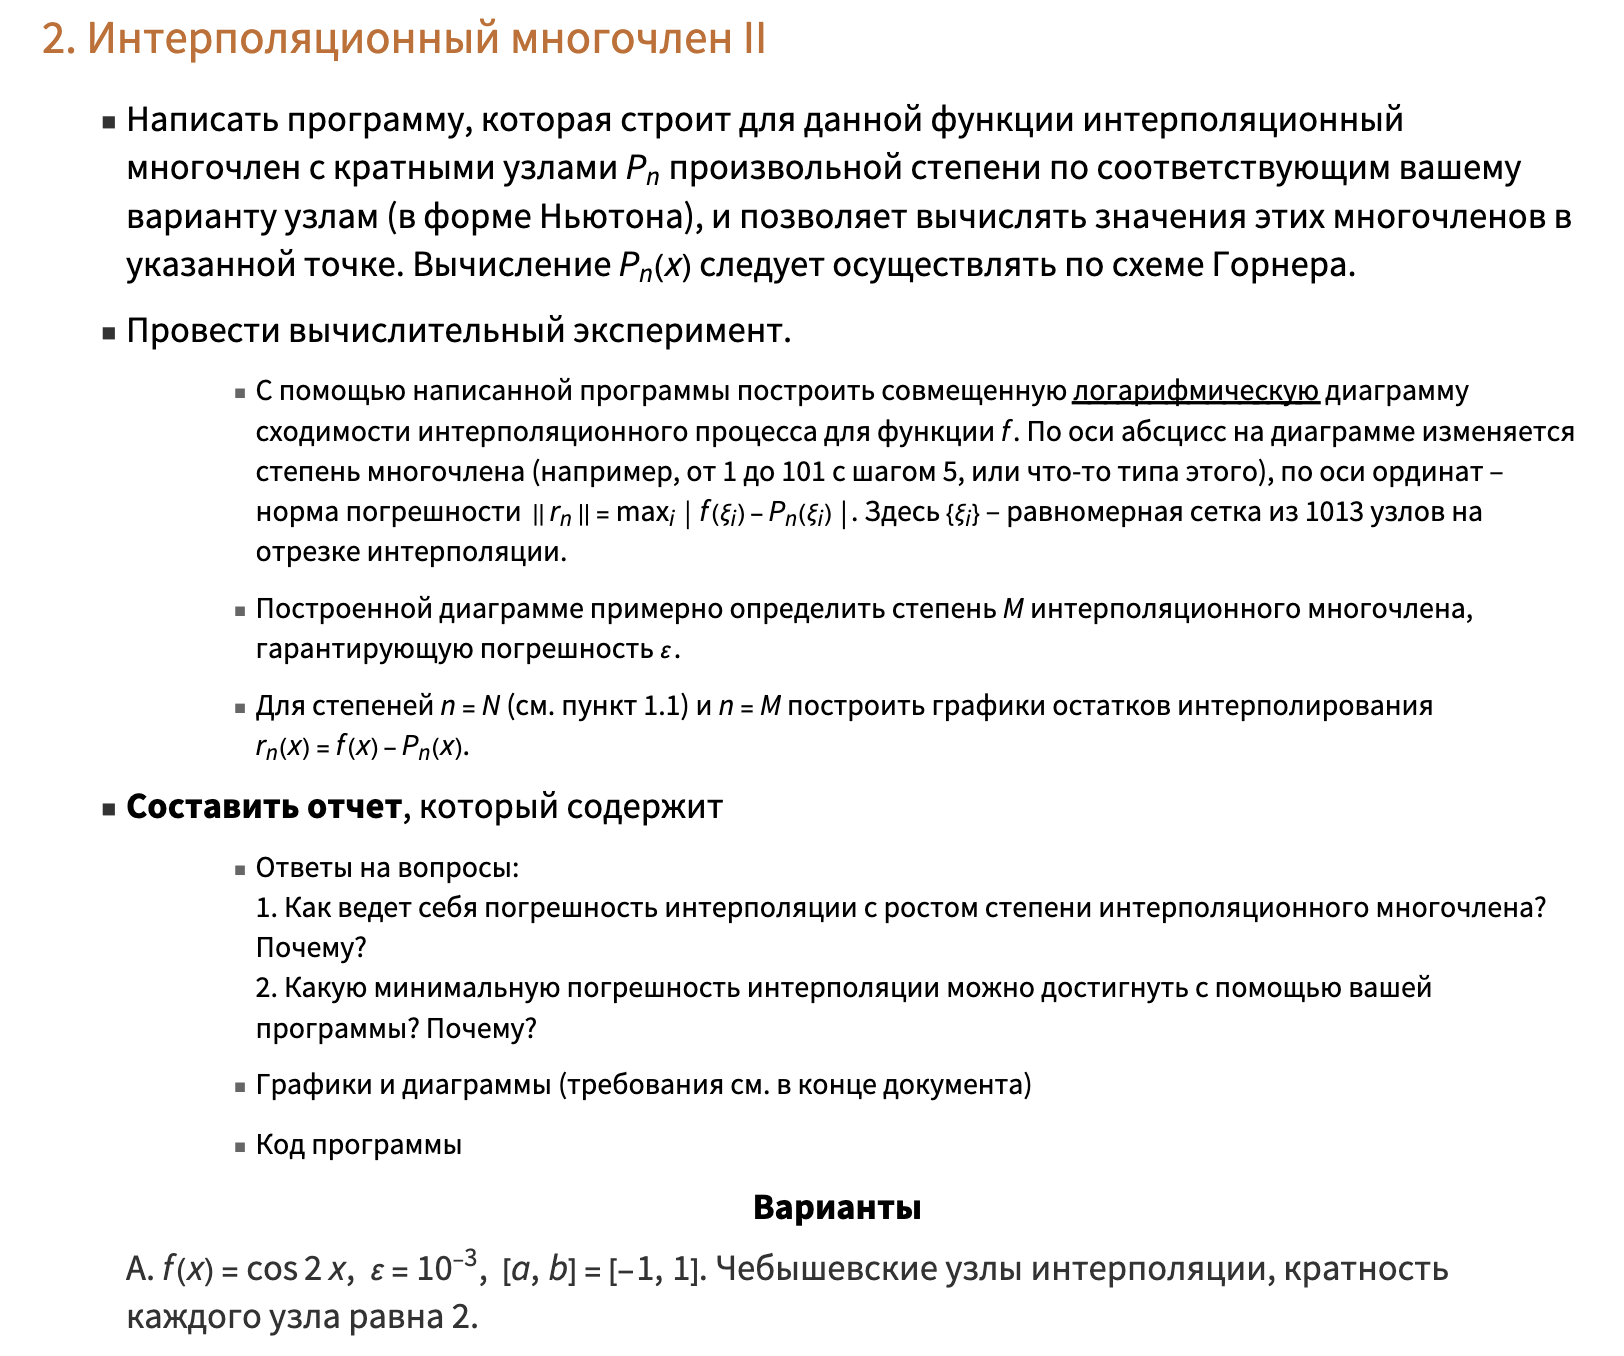

пункт 1.1

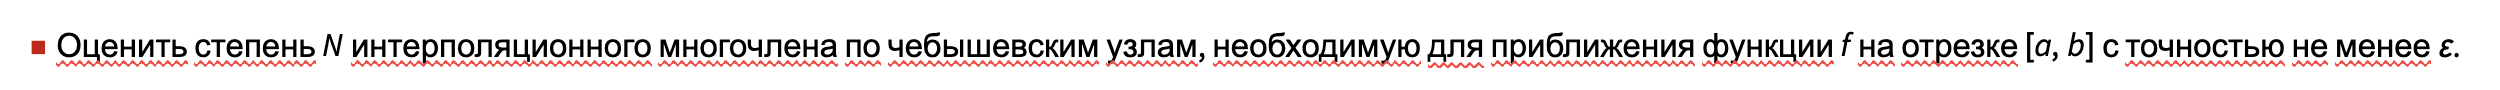

# Решение

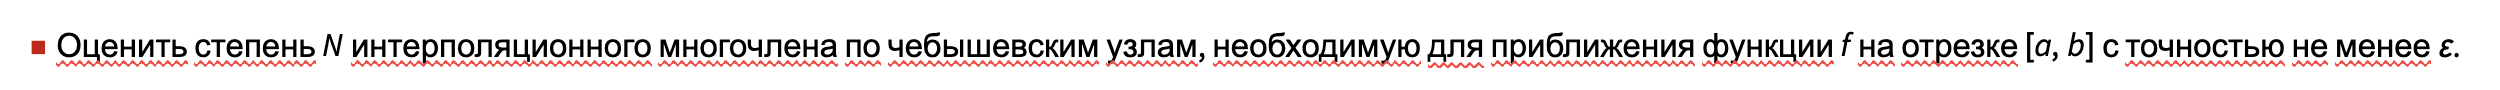

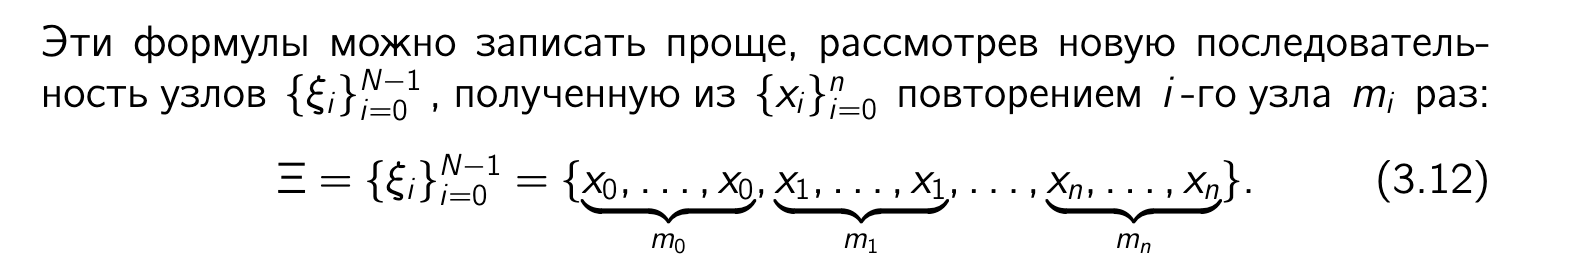

3.13

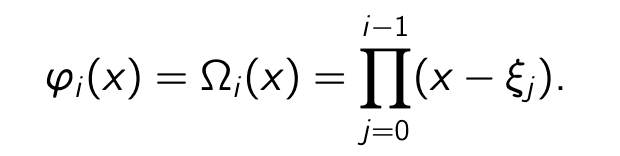

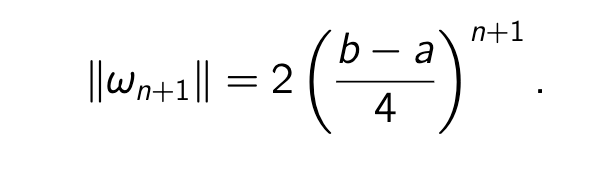

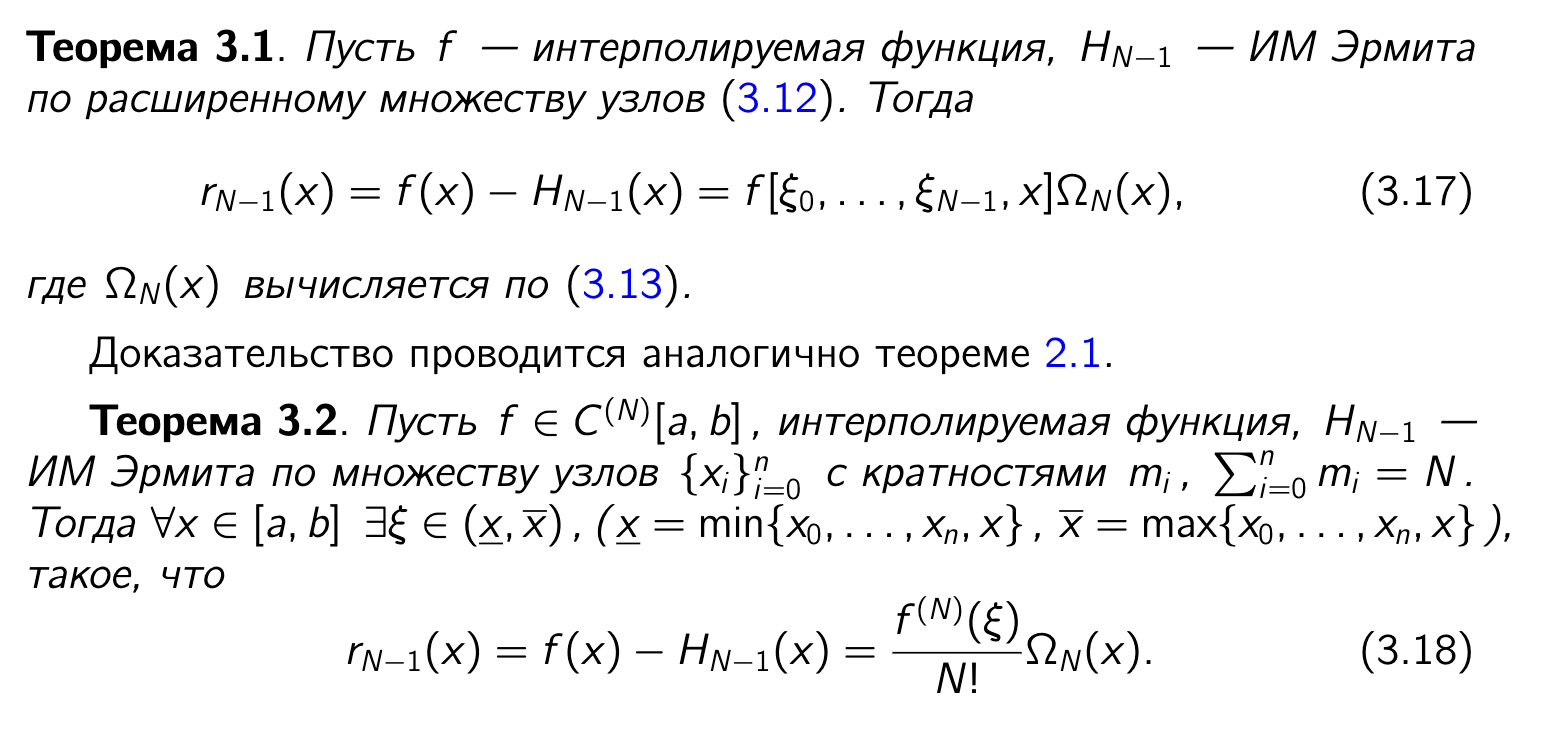

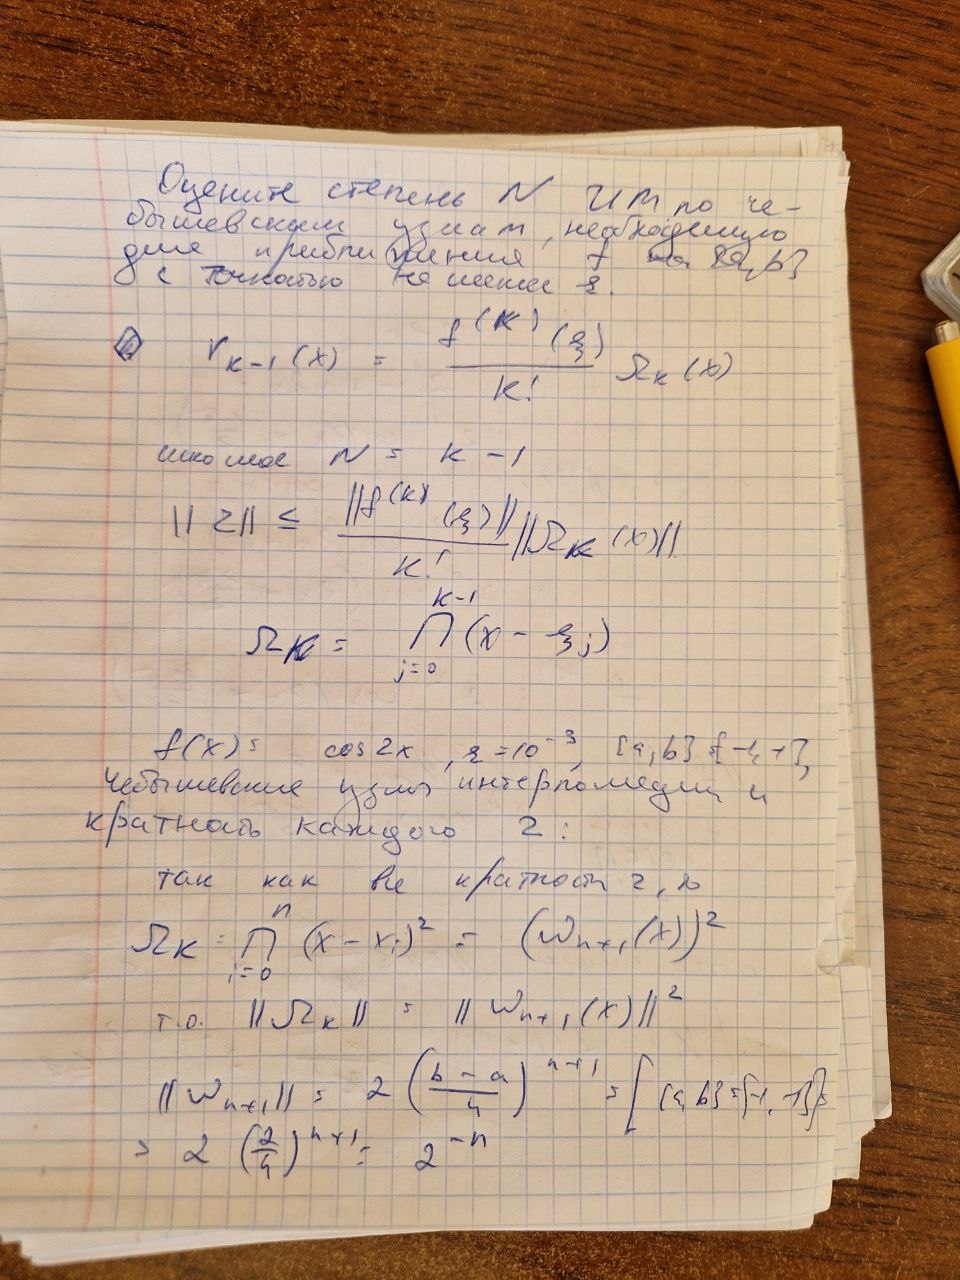

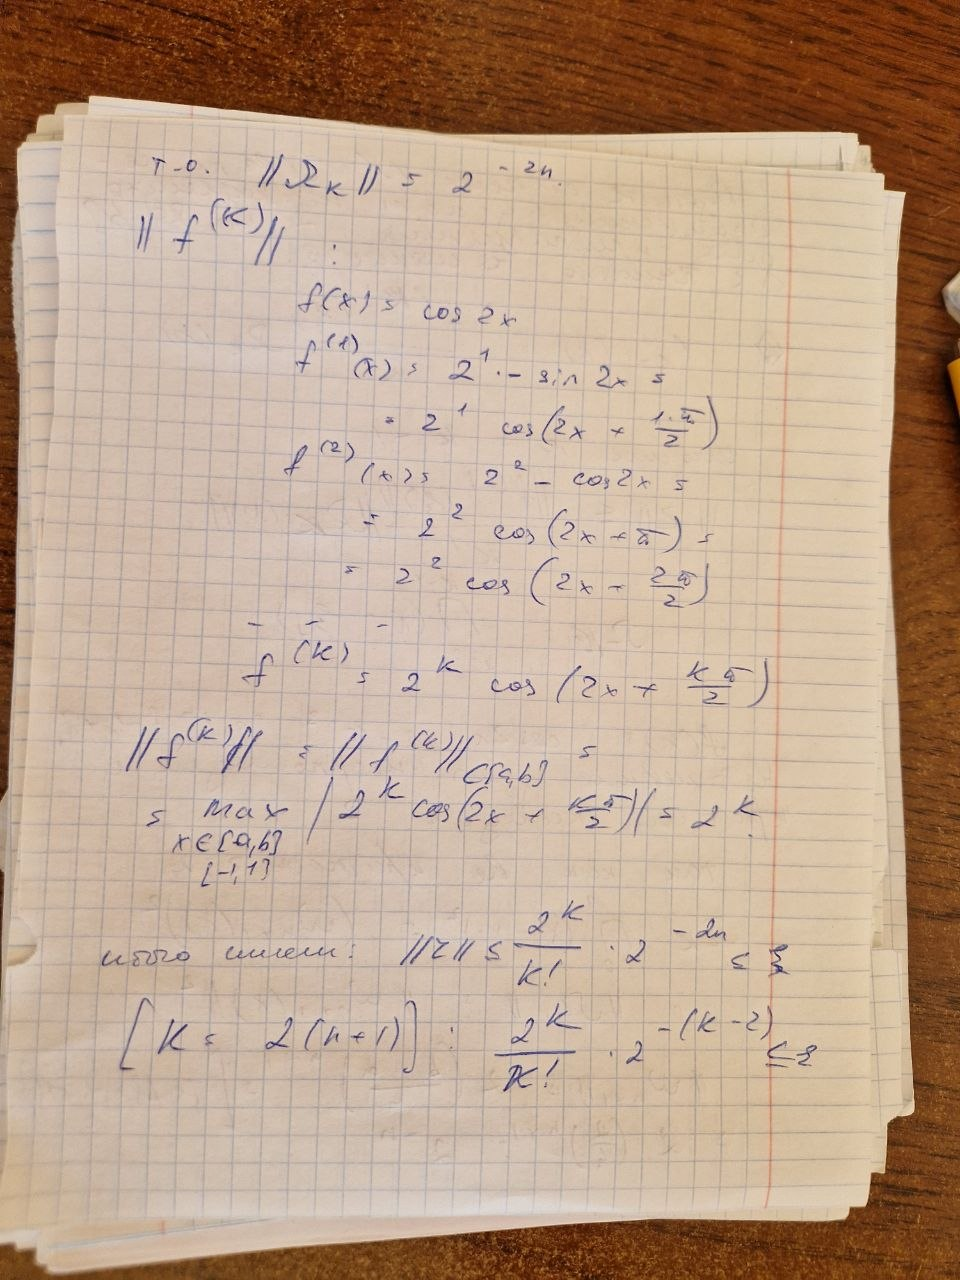

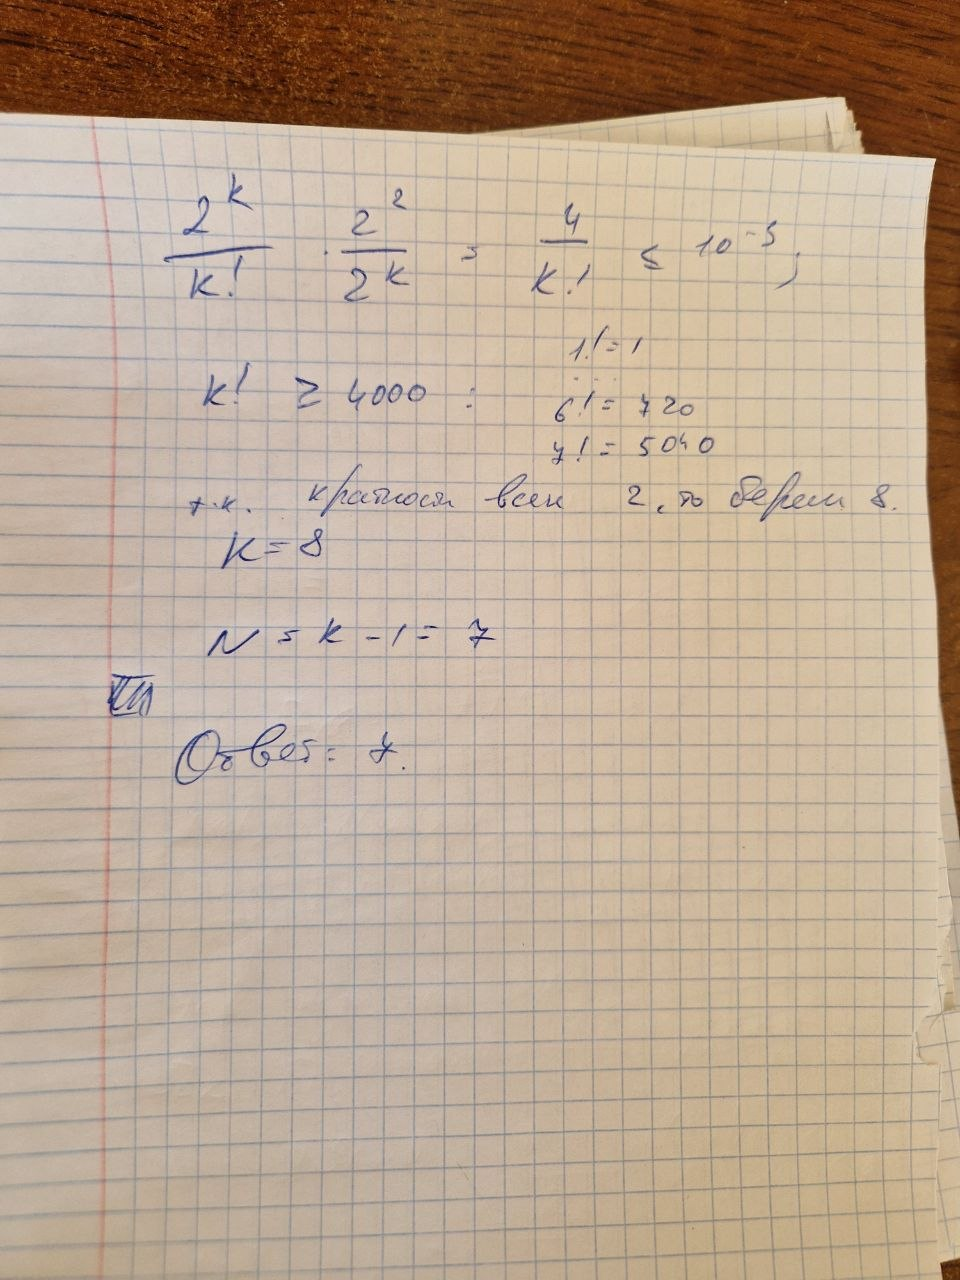

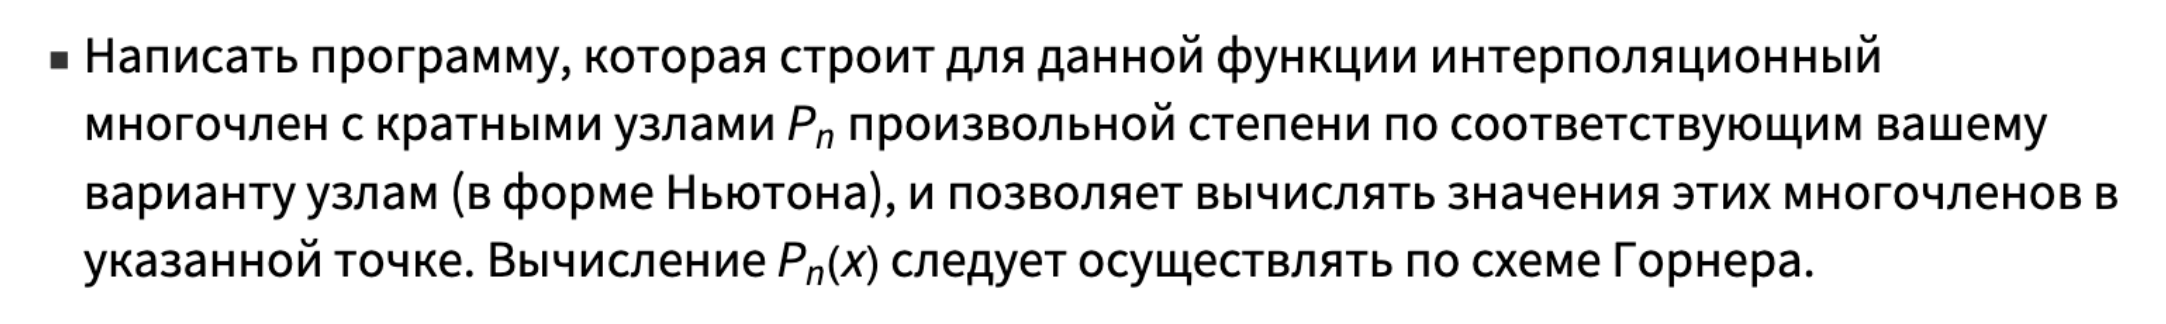

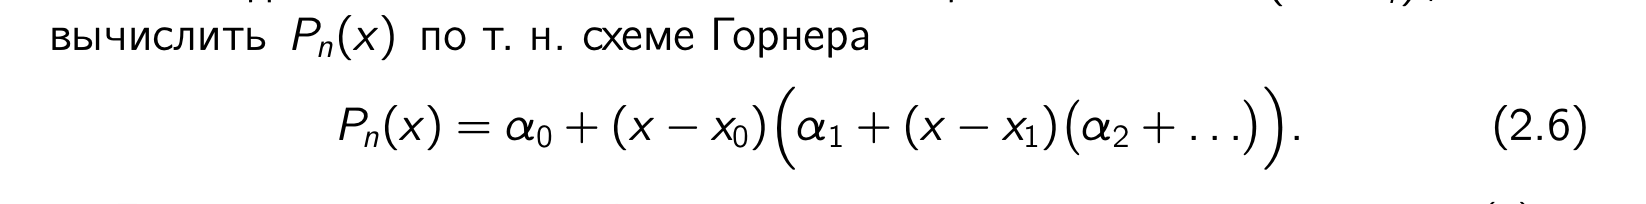

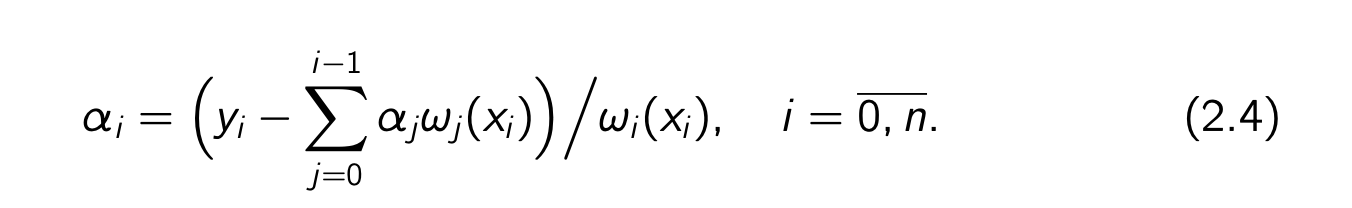

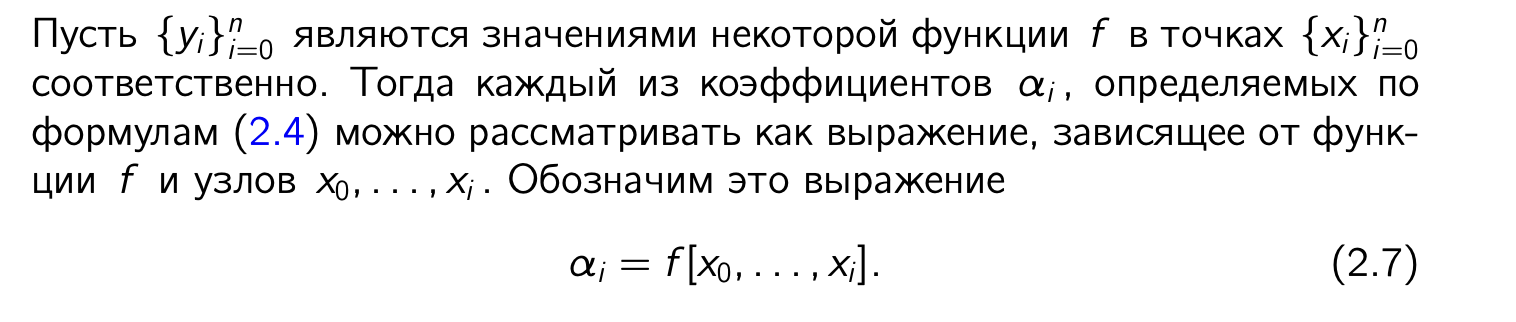

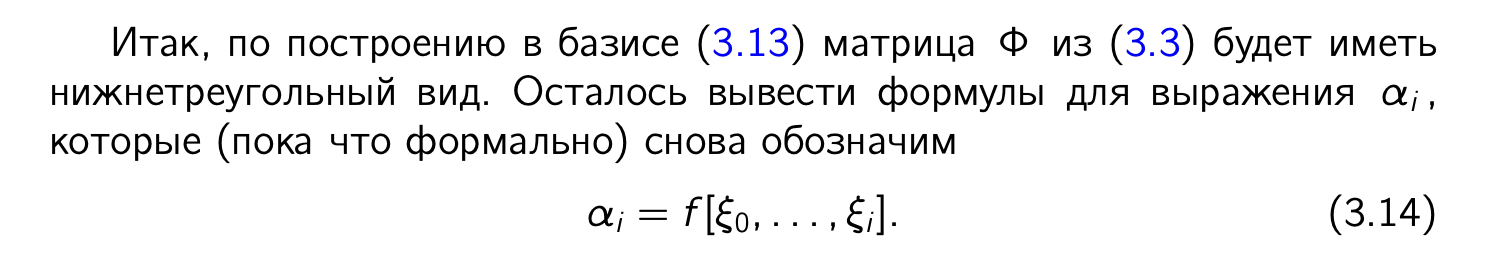

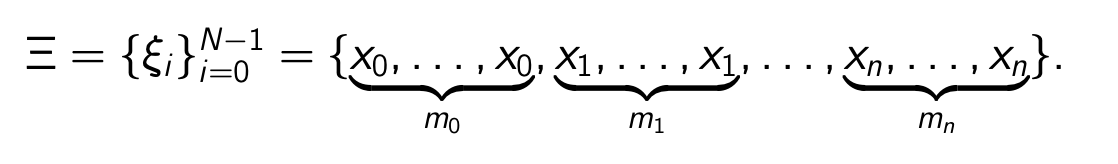

$\Xi = \{x_0, x_0, x_1, x_1, \dots, x_n, x_n\}$.

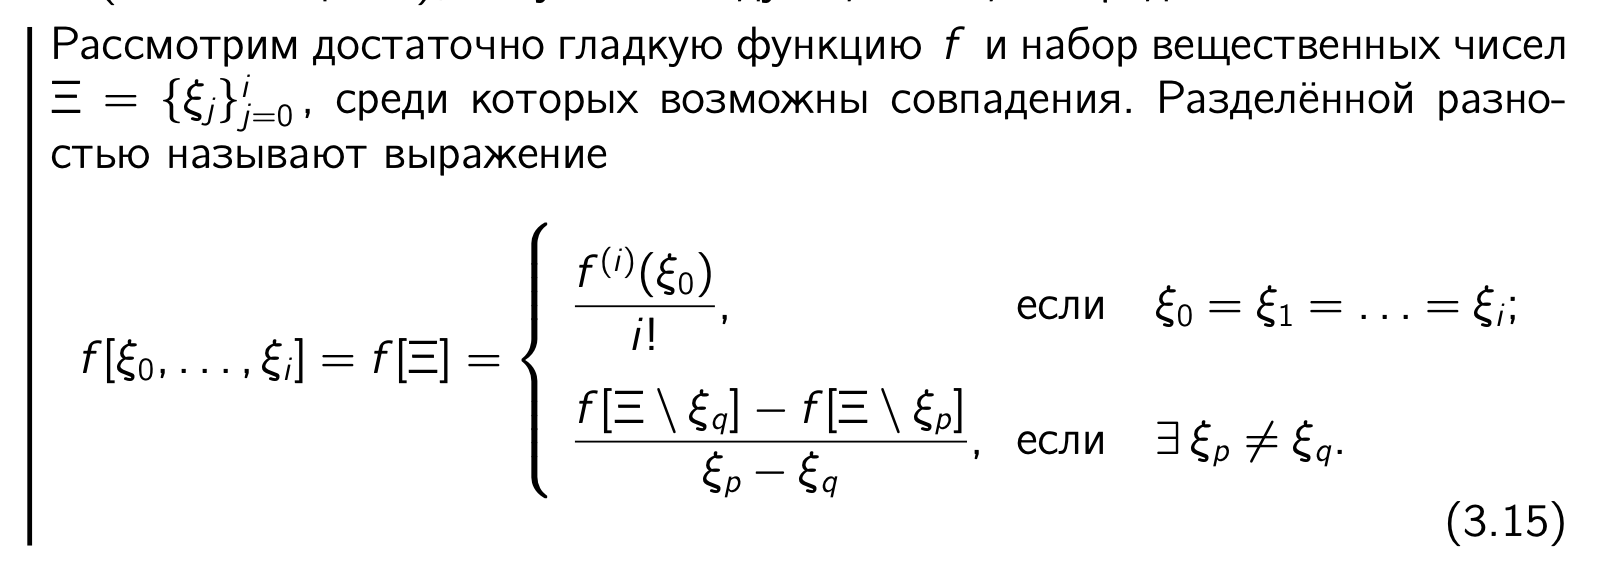

*   Если $x_i \ne x_j$: $\frac{f(x_i) - f(x_j)}{x_i - x_j}$.
*   Если кратны И при условии, что у нас кратность 2: $\frac{f'(x_i)}{1!}$.

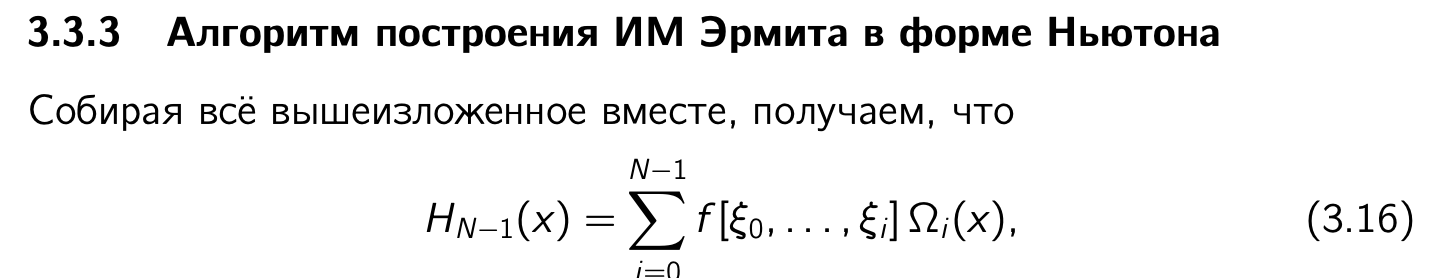

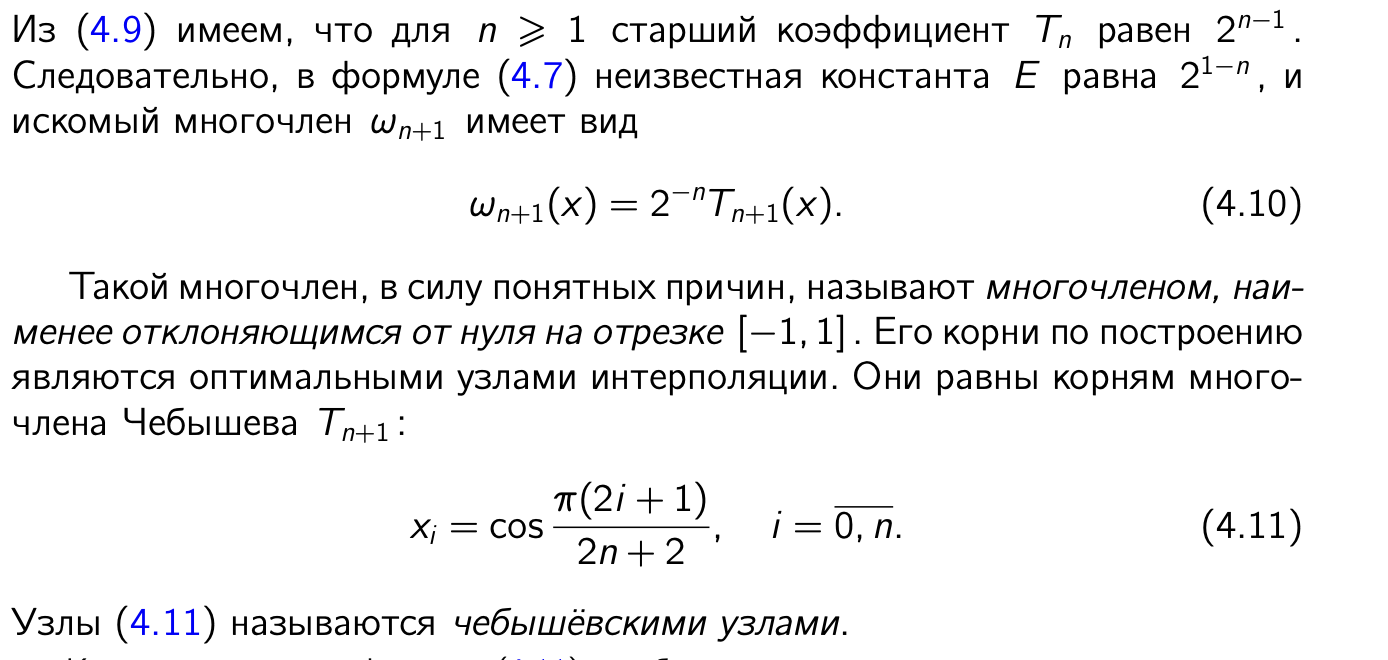

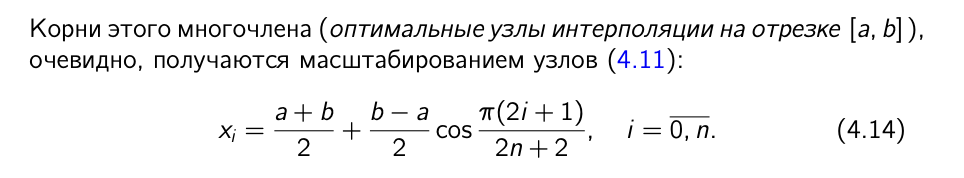

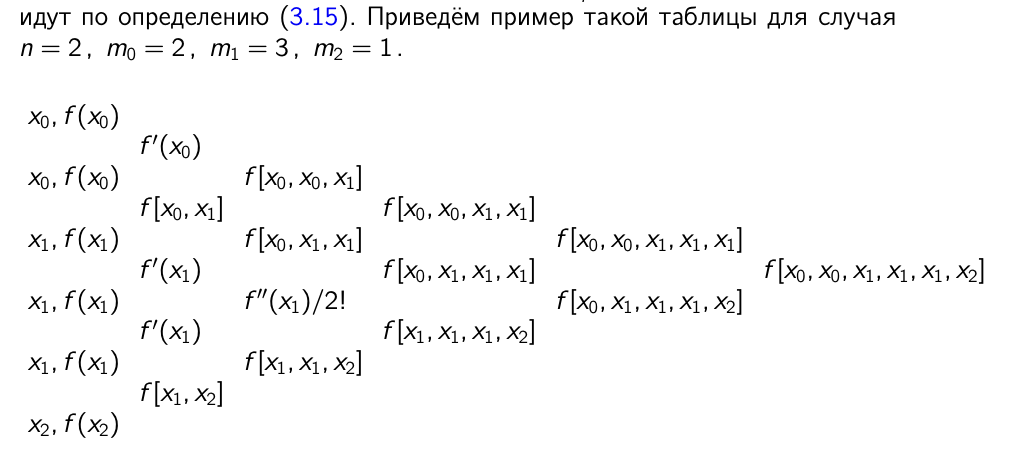

найдем $n$:
$$ K = 2(n + 1) $$
$$ 8 = 2(n + 1) $$
$$ 4 = n + 1 $$
$$ n = 3$$

In [1]:
import numpy as np

# исходная фунция
def f(x): 
    return np.cos(2 * x)

# ее производная
def df(x):
    return -2 * np.sin(2 * x)

# получить узлы Чебышева
def get_chebyshev_nodes(
    n, # n+1 -- количество различных узлов
    a, b): # [a,b]
    indices = np.arange(n + 1) # массив от 0 до n
    nodes = np.cos((np.pi * (2 * indices + 1)) / (2 * n + 2)) # узлы чебышева
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes # масштабирование

# построение таблицы разделенных разностей для кратных узлов
def build_hermite_table(
    nodes, # уникальные узлы
    multiplicity=2): # кратность каждого узла. по условию 2

    # Xi
    xi = np.repeat(nodes, multiplicity)
    n_total = len(xi)
    
    # таблица разностей: n_total строк на n_total столбцов
    table = np.zeros((n_total, n_total))
    
    # первый столбец: значения функции в узлах
    table[:, 0] = f(xi)
    
    # заполняем остальное
    for j in range(1, n_total):
        for i in range(n_total - j):
            # совпадают ли узлы
            if abs(xi[i+j] - xi[i]) < 1e-12:
                table[i, j] = df(xi[i])
            else:
                table[i, j] = (table[i+1, j-1] - table[i, j-1]) / (xi[i+j] - xi[i])
                
    return xi, table[0, :]

# схема Горнера
def hornering(x, xi, alphas):
    n = len(alphas)
    res = alphas[-1]
    for i in range(n - 2, -1, -1):
        res = res * (x - xi[i]) + alphas[i]
    return res

a, b = -1, 1
# Из Пункта 1 мы нашли, что нам нужно 4 узла (n=3) для степени 7
n = 3 

# узлы
unique_nodes = get_chebyshev_nodes(n, a, b)

# таблица и альфы
xi_expanded, alphas = build_hermite_table(unique_nodes)

# пробуем что=то вычеслить
x_test = 0.5
y_poly = hornering(x_test, xi_expanded, alphas)
y_true = f(x_test)

print(f"Степень многочлена: {len(alphas)-1}")
print(f"Значение в x={x_test}: {y_poly}")
print(f"Точное значение: {y_true}")
print(f"Ошибка: {abs(y_poly - y_true)}")

Степень многочлена: 7
Значение в x=0.5: 0.5402798767315129
Точное значение: 0.5403023058681398
Ошибка: 2.2429136626866963e-05


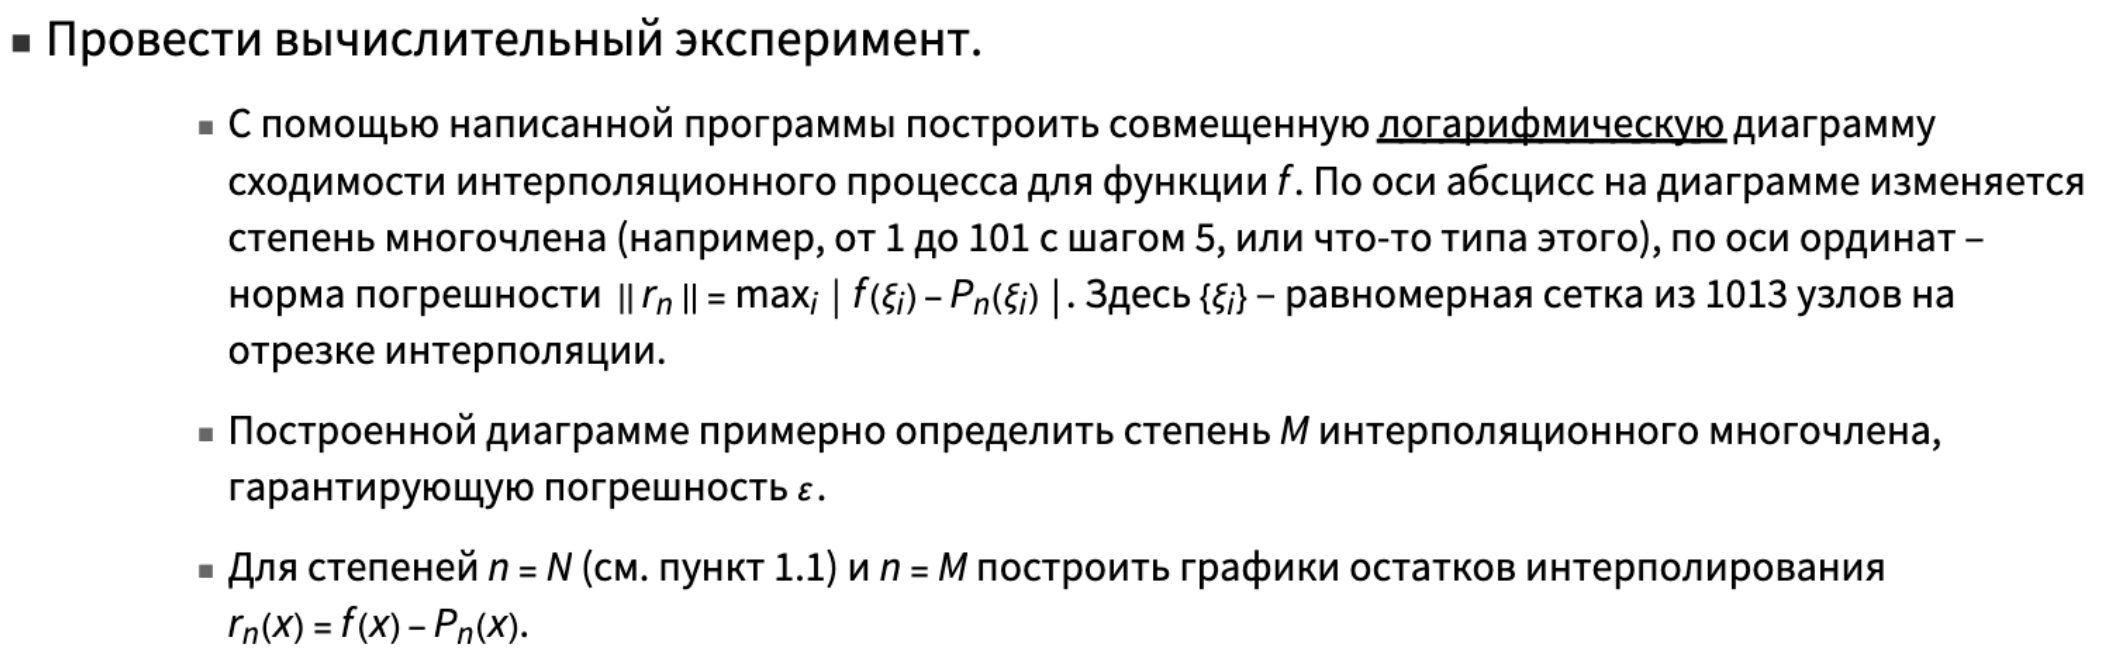